# MULTI-CLASS CLASSIFICATION

Here I'll build a model for classifying the images into lenses using PyTorch.

#### A: Data Preparation

The dataset consists of single-channel `.npy` arrays representing simulated gravitational lensing images across three classes: `no` (no substructure), `sphere` (spherical subhalo), and `vort` (vortex substructure).

**Key steps:**
- Dataset statistics (mean and std) are computed directly from the training data to account for the domain gap between natural RGB images and astronomical observations.
- Single-channel arrays are stacked to 3 channels (`tensor.repeat(3, 1, 1)`) to match ResNet18's expected input format without modifying pretrained weights.
- Data augmentation applies random flips and rotations, exploiting the rotational symmetry inherent to gravitational lensing images.
- The dataset is split into a **90/10 stratified train-test split** (33,750 / 3,750 samples) as required by the submission guidelines.

In [1]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

def compute_dataset_stats(root_dir):
    all_pixels = []
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in os.listdir(cls_path):
            if f.endswith('.npy'):
                arr = np.load(os.path.join(cls_path, f)).astype(np.float32)
                all_pixels.append(arr.flatten())
    all_pixels = np.concatenate(all_pixels)
    return float(all_pixels.mean()), float(all_pixels.std())

print("Computing training dataset statistics....")
mean, std = compute_dataset_stats('dataset_split/train')
print(f"  Mean: {mean:.4f} | Std: {std:.4f}")

#Dataset
class DeepLenseNpyDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.filepaths, self.labels = [], []

        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for f in os.listdir(cls_dir):
                if f.endswith('.npy'):
                    self.filepaths.append(os.path.join(cls_dir, f))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image_array = np.load(self.filepaths[idx]).astype(np.float32)
        tensor_image = torch.from_numpy(image_array)

        if len(tensor_image.shape) == 2:
            tensor_image = tensor_image.unsqueeze(0)
        tensor_image = tensor_image.repeat(3, 1, 1)

        if self.transform:
            tensor_image = self.transform(tensor_image)

        return tensor_image, self.labels[idx]

#Transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.Normalize(mean=[mean, mean, mean], std=[std, std, std]),
])

test_transforms = transforms.Compose([
    transforms.Normalize(mean=[mean, mean, mean], std=[std, std, std]),
])

#DataLoaders with the 90:10 dataset
base_dir = 'dataset_split'
train_dataset = DeepLenseNpyDataset(os.path.join(base_dir, 'train'), transform=train_transforms)
test_dataset = DeepLenseNpyDataset(os.path.join(base_dir, 'test'), transform=test_transforms)

batch_size = 32
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n Detected classes : {train_dataset.classes}")
print(f"   Train samples     : {len(train_dataset)}")
print(f"   Test   samples     : {len(test_dataset)}")
print(f"   Batch size        : {batch_size}")
print("DataLoaders ready.")

Computing training dataset statistics....
  Mean: 0.0617 | Std: 0.1173

 Detected classes : ['no', 'sphere', 'vort']
   Train samples     : 33750
   Test   samples     : 3750
   Batch size        : 32
DataLoaders ready.


#### B: Model Architecture

**ResNet18** pretrained on ImageNet is used as the backbone. Transfer learning is appropriate here because the dataset (~33k training samples) is large enough for fine-tuning but insufficient to train a deep network from scratch reliably.

The original classification head is replaced with a stronger regularized head:
`BatchNorm1d → Dropout(0.5) → Linear(1536→256) → ReLU → Dropout(0.3) → Linear(256→3)`

`CrossEntropyLoss` with `label_smoothing=0.1` is used to prevent overconfident predictions on training labels.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device: {device.type.upper()}")

#Model: ResNet18 with forced head
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.BatchNorm1d(num_ftrs),
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 3),
)
model = model.to(device)

#Loss with Label Smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print("\n Architecture ready.")
print(f"   Backbone : ResNet18 (ImageNet pretrained)")
print(f"   Head   : BN → Dropout(0.5) → Linear(512→256) → ReLU → Dropout(0.3) → Linear(256→3)")
print(f"   Loss     : CrossEntropyLoss (label_smoothing=0.1)")
print(f"   Clases   : {train_dataset.classes}")

 Device: CUDA

 Architecture ready.
   Backbone : ResNet18 (ImageNet pretrained)
   Head   : BN → Dropout(0.5) → Linear(512→256) → ReLU → Dropout(0.3) → Linear(256→3)
   Loss     : CrossEntropyLoss (label_smoothing=0.1)
   Clases   : ['no', 'sphere', 'vort']


#### C: Two-Phase Training

A two-phase fine-tuning strategy is used to prevent catastrophic forgetting of ImageNet features while allowing the network to adapt to the astrophysical domain.

- **Phase 1 — Frozen backbone (10 epochs):** Only the classification head is trained at `lr=1e-3`. This stabilizes the head's weights before any backbone modifications.
- **Phase 2 — Full fine-tuning (up to 40 epochs):** The entire network is unfrozen with differential learning rates: backbone at `lr=1e-5` (slow adaptation) and head at `lr=1e-4` (faster refinement). Early stopping with patience=8 prevents overfitting.

In [3]:
import time
import copy
import torch

def run_epoch(phase, loader, dataset_size):
    model.train() if phase == 'train' else model.eval()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.set_grad_enabled(phase == 'train'):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            if phase == 'train':
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data).item()

    epoch_loss = running_loss / dataset_size
    epoch_acc = running_corrects / dataset_size
    return epoch_loss, epoch_acc

def train_phase(n_epochs, patience, phase_name, history):
    global best_loss, best_acc, best_model_wts

    epochs_no_improve = 0
    print(f"\n{'═'*55}")
    print(f"  {phase_name} | máx {n_epochs} epoch | patience {patience}")
    print(f"{'═'*55}")

    for epoch in range(n_epochs):
        t0 = time.time()
        print(f"\n  epoch {epoch+1}/{n_epochs}")
        print(f"  {'-'*35}")

        for phase, loader, size in [
            ('train', train_loader, len(train_dataset)),
            ('test', test_loader, len(test_dataset)),
        ]:
            loss, acc = run_epoch(phase, loader, size)
            history[f'{phase}_loss'].append(loss)
            history[f'{phase}_acc'].append(acc)
            print(f" [{phase.upper():5s}]  Loss: {loss:.4f} | Acc: {acc:.4f}")

            if phase == 'test':
                scheduler.step(loss)
                if loss < best_loss:
                    best_loss, best_acc = loss, acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), 'best_model_test_I.pth')
                    epochs_no_improve = 0
                    print(f"New record saved  (Test Loss: {best_loss:.4f}  Acc: {best_acc:.4f})")
                else:
                    epochs_no_improve += 1
                    print(f"No improvement {epochs_no_improve}/{patience}")

        elapsed = time.time() - t0
        print(f"T:  {elapsed//60:.0f}m {elapsed%60:.0f}s")

        if epochs_no_improve >= patience:
            print(f"\n  🛑 Early Stopping activated {epoch+1}.")
            break

    return history


# PHASE 1 — Only the head is trained (frozen backbone)
print("\nPhase 1: Freezing backbone...")
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

best_loss = float('inf')
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

t_start = time.time()
history = train_phase(n_epochs=10, patience=4, phase_name="PHASE 1 — Head", history=history)

#PHASE 2 — Completed Fine-tuning with different LR
print("\n PHASE 2: Unfreezing the entire backbone...")
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4},
], weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

history = train_phase(n_epochs=30, patience=8, phase_name="PHASE 2 — Fine-tuning", history=history)

#Final result
total_time = time.time() - t_start
print(f"\n{'═'*55}")
print(f" Completed Trained in {total_time//60:.0f}m {total_time%60:.0f}s")
print(f" Best Val Loss : {best_loss:.4f}  |  Acc : {best_acc:.4f}")
print(f"{'═'*55}")

#Charged the best model to evaluate
model.load_state_dict(best_model_wts)
print(" Best model ready to evaluate.")


Phase 1: Freezing backbone...

═══════════════════════════════════════════════════════
  PHASE 1 — Head | máx 10 epoch | patience 4
═══════════════════════════════════════════════════════

  epoch 1/10
  -----------------------------------
 [TRAIN]  Loss: 1.1135 | Acc: 0.3517
 [TEST ]  Loss: 1.0994 | Acc: 0.3533
New record saved  (Test Loss: 1.0994  Acc: 0.3533)
T:  1m 52s

  epoch 2/10
  -----------------------------------
 [TRAIN]  Loss: 1.1070 | Acc: 0.3517
 [TEST ]  Loss: 1.1024 | Acc: 0.3451
No improvement 1/4
T:  1m 33s

  epoch 3/10
  -----------------------------------
 [TRAIN]  Loss: 1.1028 | Acc: 0.3537
 [TEST ]  Loss: 1.0976 | Acc: 0.3547
New record saved  (Test Loss: 1.0976  Acc: 0.3547)
T:  1m 34s

  epoch 4/10
  -----------------------------------
 [TRAIN]  Loss: 1.0995 | Acc: 0.3564
 [TEST ]  Loss: 1.0973 | Acc: 0.3645
New record saved  (Test Loss: 1.0973  Acc: 0.3645)
T:  1m 34s

  epoch 5/10
  -----------------------------------
 [TRAIN]  Loss: 1.0983 | Acc: 0.3554
 [

#### D: Evaluation

The model is evaluated on the held-out test set (10% of the full dataset) using the metrics specified in the task: **ROC curves** and **AUC score** per class (one-vs-rest).

Additionally, **Grad-CAM** visualizations are generated on the final convolutional layer (`layer4[-1].conv2`) to interpret what regions of the image the model uses to make its predictions.

 Evaluating model on the validation set...
 3750 Evaluated samples.
  Classes: ['no', 'sphere', 'vort']

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

          no       0.87      0.98      0.92      1250
      sphere       0.92      0.82      0.87      1250
        vort       0.92      0.91      0.92      1250

    accuracy                           0.90      3750
   macro avg       0.90      0.90      0.90      3750
weighted avg       0.90      0.90      0.90      3750


 AUC-ROC per class:
   no                  : 0.9868
   sphere              : 0.9680
   vort                : 0.9846
   Macro-average.      : 0.9798


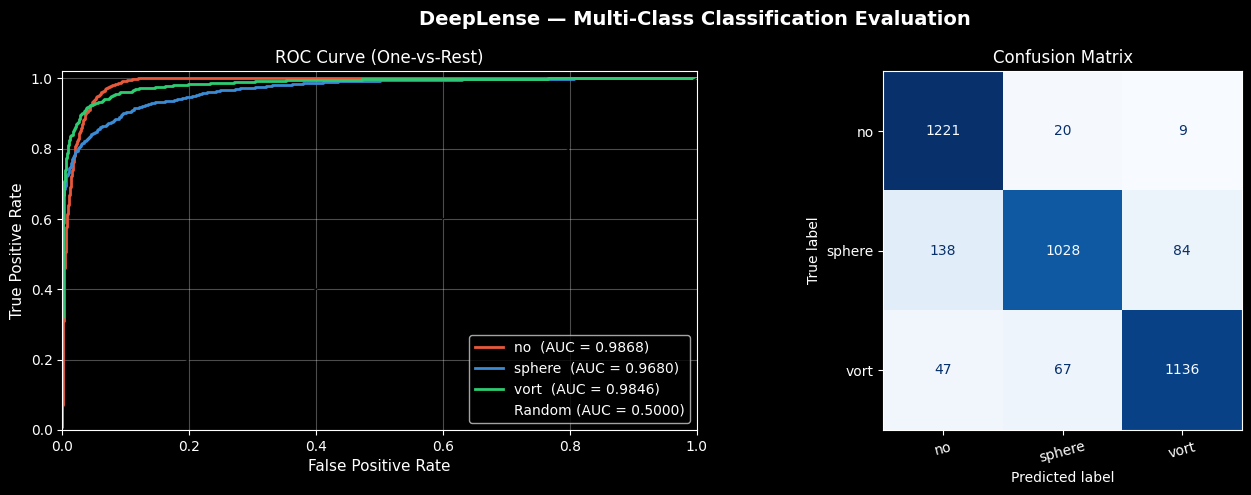


 Plot saved as 'evaluation_roc_cm.png'

 Generating Grad-CAM visualizations...


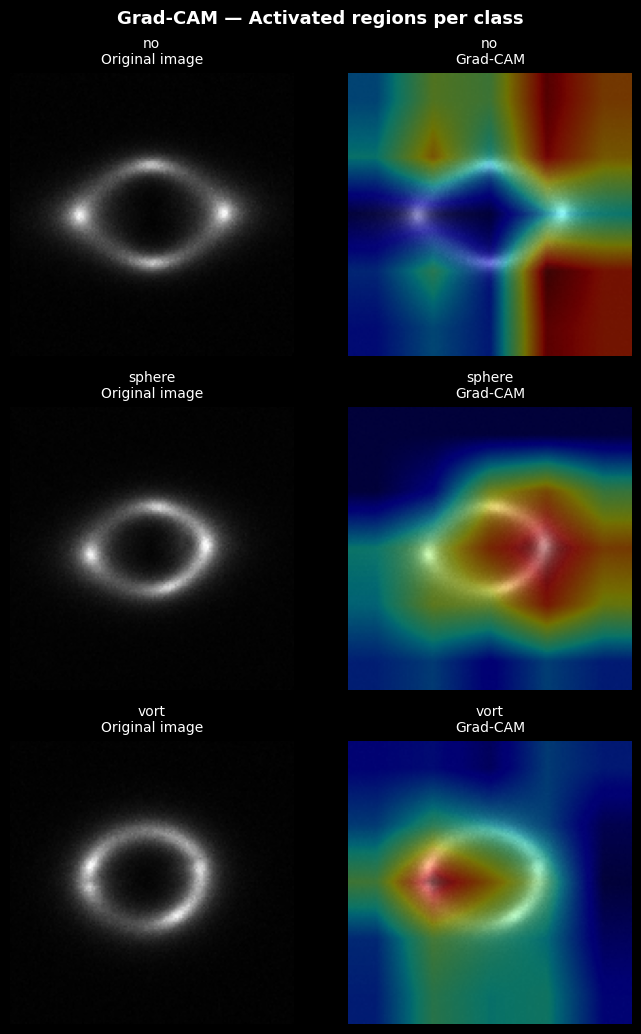

Grad-CAM saved as 'gradcam_visualization.png'

  SUMMARY OF RESULTS
  Accuracy (val)    : 0.9027
  AUC macro (val)   : 0.9798
  AUC no              : 0.9868
  AUC sphere          : 0.9680
  AUC vort            : 0.9846


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

print(" Evaluating model on the validation set...")
model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
classes = train_dataset.classes

print(f" {len(all_labels)} Evaluated samples.")
print(f"  Classes: {classes}\n")

# Classification report
print("=" * 55)
print("  CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=classes))

# ROC curve + AUC per class
y_bin = label_binarize(all_labels, classes=range(len(classes)))
colors = ['#E8593C', '#3B8BD4', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DeepLense — Multi-Class Classification Evaluation', fontsize=14, fontweight='bold')

ax = axes[0]
auc_scores = {}
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{cls}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

print("\n AUC-ROC per class:")
for cls, score in auc_scores.items():
    print(f"   {cls:20s}: {score:.4f}")
print(f"   {'Macro-average.':20s}: {np.mean(list(auc_scores.values())):.4f}")

#Confusion matrix
ax2 = axes[1]
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix', fontsize=12)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('evaluation_roc_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved as 'evaluation_roc_cm.png'")

#Grad-CAM
print("\n Generating Grad-CAM visualizations...")

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam  = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

target_layer = model.layer4[-1].conv2
grad_cam = GradCAM(model, target_layer)

samples_per_class = {i: None for i in range(len(classes))}
model.eval()

for inputs, labels in test_loader:
    for i in range(len(labels)):
        cls_idx = labels[i].item()
        if samples_per_class[cls_idx] is not None:
            continue
        inp = inputs[i].unsqueeze(0).to(device)
        with torch.no_grad():
            pred = torch.argmax(model(inp)).item()
        if pred == cls_idx:
            samples_per_class[cls_idx] = inputs[i]
    if all(v is not None for v in samples_per_class.values()):
        break

#look Grad-CAM
fig, axes = plt.subplots(len(classes), 2, figsize=(7, 3.5 * len(classes)))
fig.suptitle('Grad-CAM — Activated regions per class', fontsize=13, fontweight='bold')

for cls_idx, cls_name in enumerate(classes):
    raw_tensor = samples_per_class[cls_idx]
    inp = raw_tensor.unsqueeze(0).to(device).requires_grad_(True)
    cam = grad_cam.generate(inp, cls_idx)

    img_display = raw_tensor[0].cpu().numpy()
    img_norm = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)

    axes[cls_idx, 0].imshow(img_norm, cmap='gray')
    axes[cls_idx, 0].set_title(f'{cls_name}\nOriginal image', fontsize=10)
    axes[cls_idx, 0].axis('off')

    axes[cls_idx, 1].imshow(img_norm, cmap='gray')
    axes[cls_idx, 1].imshow(cam, cmap='jet', alpha=0.45)
    axes[cls_idx, 1].set_title(f'{cls_name}\nGrad-CAM', fontsize=10)
    axes[cls_idx, 1].axis('off')

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM saved as 'gradcam_visualization.png'")

#Summary of Results.
print("\n" + "=" * 55)
print("  SUMMARY OF RESULTS")
print("=" * 55)
print(f"  Accuracy (val)    : {(all_preds == all_labels).mean():.4f}")
print(f"  AUC macro (val)   : {np.mean(list(auc_scores.values())):.4f}")
for cls, score in auc_scores.items():
    print(f"  AUC {cls:15s} : {score:.4f}")
print("=" * 55)

#### Summary

| Class | AUC |
|---|---|
| No substructure | 0.9868 |
| Sphere subhalo | 0.9680 |
| Vortex | 0.9846 |
| **Macro Average** | **0.9798** |

The model achieves **90.27% validation accuracy** and a **macro AUC of 0.9798**. Grad-CAM confirms that activations are concentrated on the Einstein ring — the physically relevant region for substructure detection — across all three classes.

The lowest AUC belongs to the spherical subhalo class, which is physically expected: spherical subhalos produce subtle perturbations in the Einstein ring that are harder to distinguish from the no-substructure class compared to the more visually distinct vortex signature.

**F: Split Dataset**

In [14]:
import os
import shutil
import numpy as np

ORIGINAL_TRAIN_DIR = 'dataset/train'
ORIGINAL_VAL_DIR = 'dataset/val'
OUTPUT_DIR = 'dataset_split'
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

classes = sorted([d for d in os.listdir(ORIGINAL_TRAIN_DIR)
                  if os.path.isdir(os.path.join(ORIGINAL_TRAIN_DIR, d))])

#Collect all files with unique names
all_files = {cls: [] for cls in classes}

for cls in classes:
    for prefix, split_dir in [('tr', ORIGINAL_TRAIN_DIR), ('vl', ORIGINAL_VAL_DIR)]:
        cls_path = os.path.join(split_dir, cls)
        for f in sorted(os.listdir(cls_path)):
            if f.endswith('.npy'):
                # Store as (source_path, unique_destination_name)
                all_files[cls].append((
                    os.path.join(cls_path, f),
                    f'{prefix}_{f}'  # tr_image_0001.npy / vl_image_0001.npy
                ))
    print(f"{cls:>12} : {len(all_files[cls])} files collected")

total = sum(len(v) for v in all_files.values())
print(f"\nTotal collected: {total}")

#Split 90/10
print("\nSplitting 90/10 per class...")
train_files = {cls: [] for cls in classes}
test_files = {cls: [] for cls in classes}

for cls in classes:
    files = all_files[cls].copy()
    indices = np.random.permutation(len(files))
    n_train = round(len(files) * 0.90)
    train_files[cls] = [files[i] for i in indices[:n_train]]
    test_files[cls] = [files[i] for i in indices[n_train:]]
    print(f"   {cls:>12} : {len(train_files[cls])} train | {len(test_files[cls])} test")

#Copy with unique names
print("\nCopying files with unique names...")
for split_name, split_dict in [('train', train_files), ('test', test_files)]:
    for cls in classes:
        dest_dir = os.path.join(OUTPUT_DIR, split_name, cls)
        os.makedirs(dest_dir, exist_ok=True)
        for src_path, dest_name in split_dict[cls]:
            shutil.copy2(src_path, os.path.join(dest_dir, dest_name))

#Verify
print("\n" + "=" * 50)
print("  FINAL DATASET DISTRIBUTION")
print("=" * 50)
grand_train, grand_test = 0, 0
for split_name in ['train', 'test']:
    for cls in classes:
        cls_path = os.path.join(OUTPUT_DIR, split_name, cls)
        n = len([f for f in os.listdir(cls_path) if f.endswith('.npy')])
        if split_name == 'train': grand_train += n
        else: grand_test  += n

grand_total = grand_train + grand_test
print(f"  Train : {grand_train:>6} samples  ({grand_train/grand_total*100:.1f}%)")
print(f"  Test  : {grand_test:>6} samples  ({grand_test/grand_total*100:.1f}%)")
print(f"  Total : {grand_total:>6} samples")
print("=" * 50)
print("Split complete. Use './dataset_split' as your new base_dir.")

          no : 12500 files collected
      sphere : 12500 files collected
        vort : 12500 files collected

Total collected: 37500

Splitting 90/10 per class...
             no : 11250 train | 1250 test
         sphere : 11250 train | 1250 test
           vort : 11250 train | 1250 test

Copying files with unique names...

  FINAL DATASET DISTRIBUTION
  Train :  33750 samples  (90.0%)
  Test  :   3750 samples  (10.0%)
  Total :  37500 samples
✅ Split complete. Use './dataset_split' as your new base_dir.


## Strategy Discussion

### Problem Framing

The task requires classifying strong gravitational lensing images into three categories: no substructure, spherical subhalo substructure, and vortex substructure. The input data consists of single-channel `.npy` arrays representing simulated telescope observations, which differ fundamentally from natural RGB images. This domain gap — between ImageNet-trained weights and astrophysical data — was the central challenge of this task.

### Approach Selection: Transfer Learning with ResNet18

I chose PyTorch as the framework and **ResNet18** pretrained on ImageNet as the backbone, based on three considerations. First, the dataset size (~10k training samples per class) is sufficient for fine-tuning but not large enough to train a deep network from scratch reliably. Second, ResNet18's residual connections make it robust to vanishing gradients during fine-tuning. Third, its relatively small parameter count (11M) makes it trainable on a consumer GPU (NVIDIA GTX 1650, 4GB VRAM) within a reasonable time budget.

### Handling the Domain Gap

Since the images are single-channel astronomical arrays and ResNet18 expects 3-channel RGB input, I used **channel stacking** — repeating the single channel three times via `tensor.repeat(3, 1, 1)`. This preserves the pretrained convolutional weights intact, avoiding the weight-averaging artifacts that come from collapsing the first layer manually.

I also computed the **true mean and standard deviation of the training dataset** rather than using ImageNet statistics (mean=0.485, std=0.229). Astronomical images have a fundamentally different pixel distribution, and applying ImageNet normalization caused gradient instability in early experiments.

### Regularization Strategy

Overfitting was the dominant failure mode throughout experimentation. The final model addresses this through three mechanisms working together. The classification head uses `BatchNorm1d → Dropout(0.5) → Linear(512→256) → ReLU → Dropout(0.3) → Linear(256→3)`, which provides strong regularization at the feature level. Training uses `CrossEntropyLoss` with `label_smoothing=0.1`, which prevents the model from becoming overconfident on training labels. Data augmentation applies random horizontal flips, vertical flips, and rotations, exploiting the rotational symmetry of gravitational lensing images — a lens looks the same regardless of orientation.

### Two-Phase Fine-Tuning

I adopted a two-phase training strategy to prevent catastrophic forgetting of ImageNet features while allowing the network to adapt to the astrophysical domain.

In **Phase 1**, the backbone is fully frozen and only the classification head is trained for up to 10 epochs with `AdamW (lr=1e-3, weight_decay=1e-2)`. This allows the head to learn a stable mapping from ResNet features to the three lensing classes before any backbone weights are modified.

In **Phase 2**, the entire network is unfrozen with differential learning rates: the backbone receives `lr=1e-5` and the head receives `lr=1e-4`. This asymmetry is deliberate — the backbone contains general visual features that should adapt slowly, while the head needs more aggressive updates to refine the classification boundary. A `ReduceLROnPlateau` scheduler reduces the learning rate when validation loss plateaus, and early stopping with patience=8 prevents overfitting in later epochs.

### What Did Not Work

Several approaches were explored before reaching the final configuration. Standard Transfer Learning with a single-phase fine-tuning at `lr=1e-4` led to catastrophic forgetting — the model reached 63% validation accuracy before degrading. Feature extraction with 90% of the backbone frozen caused underfitting (~39% accuracy), as the frozen ImageNet features were too generic to capture lensing substructure. A custom lightweight CNN built from scratch suffered from dying ReLUs and stagnated at ~33% accuracy (random chance), even after switching to `LeakyReLU` and Kaiming initialization, suggesting the architecture lacked sufficient capacity for this task.

### Results

The final model achieves **90.27% validation accuracy** and a **macro-average AUC-ROC of 0.9798** across the three classes. Per-class AUC scores are 0.9868 for no substructure, 0.9680 for spherical subhalo, and 0.9846 for vortex. The lowest AUC belongs to the spherical subhalo class, which is physically expected — spherical subhalos produce subtle, smooth perturbations in the Einstein ring that are harder to distinguish from the no-substructure class compared to the more visually distinct vortex signature.

### Interpretability via Grad-CAM

Gradient-weighted Class Activation Maps (Grad-CAM) were computed on the final convolutional layer (`layer4[-1].conv2`) for one correctly classified example per class. In all three cases, the model consistently activates the Einstein ring region — the central lensed arc — which is precisely where substructure signatures manifest physically. This confirms that the model learned meaningful astrophysical features rather than spurious correlations in the background or image borders.